# Time Series - Comparing

It's common to want a quick visual comparison between two time series -- two sensors, two sites, before/after a data-cleaning step, and so on. `TimeSeries.view_compare_times_series()` is a static method that overlays two `TimeSeries` objects on a shared time axis, alongside a histogram and CDF, so their distributions can be compared at a glance.

Covered here:

- Loading two independent `TimeSeries` objects
- Calling `view_compare_times_series()` inline (`return_fig=True`)
- Setting per-series colors via `view_specs`
- Saving the comparison to a file instead of displaying it inline

## Notebook setup

For users running this tutorial as a Jupyter Notebook, this cell must be executed first:

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Install `plans` in `google.colab`.
# Use `pip install plans` for other environments.

if "google.colab" in sys.modules:
    import os
    os.system(f"{sys.executable} -m pip install -q plans")

# This avoids warnings related to uninstalled fonts
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# define output folder
OUTPUT_DIR = Path("outputs/time-series")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Outputs will be saved to: ./{OUTPUT_DIR}")

RNG_SEED = 1
np.random.seed(RNG_SEED)

Outputs will be saved to: ./outputs\time-series


## Create two synthetic series to compare

Two Trend-Seasonality-Noise archetype series with different bases, trends, and noise levels -- a stand-in for, e.g., two different sensors or sites over the same period.

In [2]:
from plans.datasets import TimeSeries

df_site_a = TimeSeries.make_synthetic_tsn(
    start="2020-01-01",
    end="2020-02-01",
    base=100,
    freq="1h",
    trend=0.001,
    noise_sd=4.0,
    amplitude=50,
    seasonal_period="YS",
    minor_amplitude=20,
    minor_seasonal_period="D"
)

df_site_b = TimeSeries.make_synthetic_tsn(
    start="2020-01-01",
    end="2020-02-01",
    base=120,
    freq="1h",
    trend=-0.002,
    noise_sd=6.0,
    amplitude=30,
    seasonal_period="YS",
    minor_amplitude=15,
    minor_seasonal_period="D"
)

print(f"Site A rows: {len(df_site_a)}")
print(f"Site B rows: {len(df_site_b)}")

Site A rows: 745
Site B rows: 745


## Save and load both as `TimeSeries` objects

In [3]:
file_a = OUTPUT_DIR / "site_a.csv"
file_b = OUTPUT_DIR / "site_b.csv"
df_site_a.to_csv(file_a, sep=";", index=False)
df_site_b.to_csv(file_b, sep=";", index=False)

ts_a = TimeSeries(name="Site A", alias="a")
ts_a.load_data(
    file_data=file_a,
    input_dtfield="datetime",
    input_varfield="level",
    in_sep=";",
)

ts_b = TimeSeries(name="Site B", alias="b")
ts_b.load_data(
    file_data=file_b,
    input_dtfield="datetime",
    input_varfield="level",
    in_sep=";",
)

## Comparing the two series

`view_compare_times_series()` is a **static method** on `TimeSeries` -- called on the class itself, not an instance -- taking both series plus a `specs` dict of plot overrides. It draws:

- the two series overlaid on a shared time axis (left panel)
- a horizontal histogram of each series' distribution (middle panel)
- a CDF with each series' mean annotated (right panel)

Each series keeps its own color, set via `view_specs["color"]` on each object *before* calling the method, and its own label, taken from `.name`.

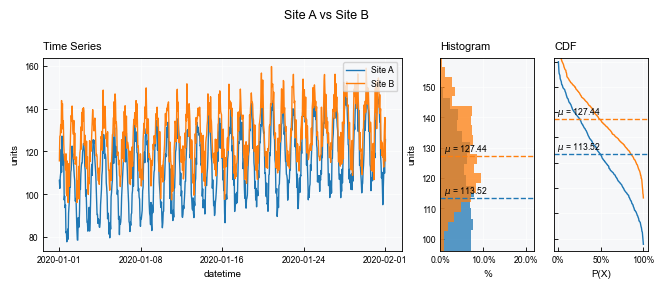

In [9]:
ts_a.view_specs["color"] = "tab:blue"
ts_b.view_specs["color"] = "tab:orange"
ts_a.view_specs["n_dates"] = 5

specs = {"title": "Site A vs Site B"}

fig = TimeSeries.view_compare_times_series(
    ts_a, ts_b, specs, return_fig=True
)
plt.show()

## Saving to a file

With `return_fig=False` (the default), the method saves the figure to disk instead of returning it. In that mode, `specs` must also include `"folder"` and `"filename"` -- these are used to build the output path (`"{folder}/{filename}.{fig_format}"`). Note that `dpi` and `fig_format` are **not** read from `specs`; they're always taken from `ts_first.view_specs` regardless of what's passed.

In [5]:
specs_save = {
    "title": "Site A vs Site B",
    "folder": str(OUTPUT_DIR),
    "filename": "site_a_vs_site_b",
}

TimeSeries.view_compare_times_series(
    ts_a, ts_b, specs_save, show=False, return_fig=False
)

saved_path = OUTPUT_DIR / f"site_a_vs_site_b.{ts_a.view_specs['fig_format']}"
print(f"Saved to: {saved_path}")
print(f"Exists: {saved_path.exists()}")

Saved to: outputs\time-series\site_a_vs_site_b.jpg
Exists: True


## Note: `view_specs` is mutated in place

Both `ts_a.view_specs` and `ts_b.view_specs` are updated in place by the call above -- the contents of `specs` get merged in, along with layout and color settings the method sets internally. If you plan to call `.view()` on either series afterward expecting its *original* single-series layout, be aware the specs have changed:

In [6]:
print(f"ts_a.view_specs['title'] after comparison call: {ts_a.view_specs['title']!r}")
print(f"ts_a.view_specs['layout'] after comparison call: {ts_a.view_specs['layout']!r}")

ts_a.view_specs['title'] after comparison call: 'Site A vs Site B'
ts_a.view_specs['layout'] after comparison call: 'mini'


## Recap

- `TimeSeries.view_compare_times_series(ts1, ts2, specs, ...)` is a static method that overlays two series with a shared histogram/CDF comparison.
- Set each series' `view_specs["color"]` beforehand to control which color it's plotted in; the label comes from `.name`.
- Use `return_fig=True` for inline display (e.g. in a notebook); omit it (or set `False`) to save to `"{folder}/{filename}.{fig_format}"`, in which case `specs` must include `"folder"` and `"filename"`.
- Both input objects' `view_specs` are mutated in place by the call -- pass copies if you need the originals preserved for later single-series `.view()` calls.